# Grain Futures Strategy — External Data as Core Signals

This notebook tests EIA ethanol, Meteostat crop-belt weather, and macro
(FX / crude / rates from yfinance) as **first-class features inside the Ridge
core model** instead of prediction-level overlays.

**Motivation.** The existing notebooks add external predictions on top of the
Cargill-aware predictions with a scalar weight. That treats the external models
as independent ensembles and forces their scale to match. Putting the raw
features into one joint Ridge regression lets the optimizer decide how much
weight each feature deserves relative to the others, and allows cross-feature
regularisation.

**What changes:**
- Core block expands from 6 features to include macro, EIA, and weather columns.
- Physical block (Cargill inventory/crush) stays as a separate strongly-regularised block.
- No external prediction overlay step at all.

**Variants tested:**
1. Baseline: original two-block model (core + physical, no external).
2. Extended core v1: original core features + macro features (alpha=25).
3. Extended core v2: original core + macro + EIA (alpha=25).
4. Extended core v3: original core + macro + EIA + weather (alpha=25).
5. Extended core v3 with tighter regularisation (alpha=100) — more features need more shrinkage.
6. Three-block model: original core (alpha=25) + external block (alpha=100) + physical (alpha=1000).
7. Walk-forward validation of the best variant (annual retrain, 20-day target).
8. Edge-filtered versions of variants 1-6.


In [1]:
from __future__ import print_function

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from grain_futures_strategy import (
    COMMODITIES,
    load_train_set,
    build_feature_panels,
    build_improved_model_signals,
    build_walk_forward_model_signals,
    fit_ridge_predict,
    model_predictions_to_positions,
    edge_filtered_positions,
    backtest_positions,
    split_performance,
    _forward_pnl_target,
    rolling_zscore,
)

%matplotlib inline
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

DATA_DIR   = 'train_set'
SPLIT_DATE = '2018-01-01'
COST_PER_LOT = 0.0

assert os.path.isdir(DATA_DIR), 'Expected train_set directory next to this notebook'
print('Config OK — split date:', SPLIT_DATE)

Config OK — split date: 2018-01-01


## Step 1 — Load Cargill data and build baseline

In [2]:
data = load_train_set(DATA_DIR)
feature_panels, futures_pnl = build_feature_panels(data)

# Baseline: original two-block model (core 6 features + physical 5 features)
baseline_predictions, _, _, _ = build_improved_model_signals(feature_panels, futures_pnl, SPLIT_DATE)
baseline_pos, baseline_edge, baseline_thresh = edge_filtered_positions(
    baseline_predictions, futures_pnl, quantile=0.50
)
baseline_bt, _ = backtest_positions(baseline_pos, futures_pnl, COST_PER_LOT)
baseline_metrics = split_performance(baseline_bt, SPLIT_DATE)

print('Baseline (static edge-filtered, original 2-block)')
display(baseline_metrics.round(3))

Baseline (static edge-filtered, original 2-block)


,in_sample,out_of_sample,full_period
days,1262.000,610.000,1872.000
total_pnl,17165.093,10303.820,27468.914
annualized_avg_pnl,3427.578,4256.660,3697.738
annualized_vol,3686.466,2841.516,3433.365
sharpe,0.930,1.498,1.077
max_drawdown,-4648.140,-2968.153,-4648.140
hit_rate,0.501,0.526,0.509
avg_daily_turnover,0.225,0.255,0.234
avg_gross_exposure,0.929,0.943,0.934


## Step 2 — Fetch external data

Three external sources:
- **yfinance** (macro): USD index, crude oil, 10-year yield, short rate, EUR/USD, BRL/USD
- **EIA** (ethanol): weekly US ethanol production and stocks — corn-demand proxy
- **Meteostat** (weather): crop-belt temperatures and precipitation by commodity

Each fetch is wrapped in try/except so the notebook degrades gracefully if a
source is unavailable.


In [3]:
# ── Macro (yfinance) ────────────────────────────────────────────────────────
macro_features = None
try:
    from macro_yfinance_experiment import _download_yfinance_prices, build_macro_feature_block
    macro_prices = _download_yfinance_prices(futures_pnl.index.min(), futures_pnl.index.max())
    macro_features = build_macro_feature_block(macro_prices, futures_pnl.index)
    print(f'Macro features: {macro_features.shape[1]} columns, '
          f'{macro_features.dropna(how="all").shape[0]} non-NaN rows')
    display(macro_features.tail(3).round(3))
except Exception as e:
    print(f'WARNING: macro fetch failed — {e}')
    print('Macro block will be skipped.')

/Users/phuongpham/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Macro features: 29 columns, 2806 non-NaN rows


,usd_index_ret_5,usd_index_ret_20,usd_index_ret_60,usd_index_vol_20,crude_oil_ret_5,crude_oil_ret_20,crude_oil_ret_60,crude_oil_vol_20,ten_year_yield_ret_5,ten_year_yield_ret_20,ten_year_yield_ret_60,ten_year_yield_vol_20,short_rate_ret_5,short_rate_ret_20,short_rate_ret_60,short_rate_vol_20,eurusd_ret_5,eurusd_ret_20,eurusd_ret_60,eurusd_vol_20,brlusd_ret_5,brlusd_ret_20,brlusd_ret_60,brlusd_vol_20,ten_year_yield_level,short_rate_level,usd_index_level,crude_oil_level,yield_curve_10y_3m
2020-12-29,0.396,-0.630,-0.735,-0.434,0.032,0.111,0.307,-0.403,-0.029,0.733,0.958,-0.581,0.083,0.032,0.031,-0.332,-0.229,0.609,0.748,-0.421,0.554,-0.683,-1.330,-0.430,0.209,-0.470,-1.742,0.804,1.257
2020-12-30,-0.482,-0.492,-0.970,-0.524,0.131,0.179,0.247,-0.407,0.179,0.181,1.061,-0.791,0.161,0.056,0.054,-0.325,-0.247,0.818,0.592,-0.484,0.628,-0.563,-1.127,-0.416,0.229,-0.443,-1.826,0.847,1.214
2020-12-31,-0.610,-0.606,-1.034,-0.479,0.065,0.156,0.301,-0.408,-0.196,0.053,0.816,-0.795,0.027,-0.022,-0.010,-0.299,0.296,0.368,0.817,-1.001,0.150,-0.309,-1.210,-0.673,0.217,-0.477,-1.922,0.892,1.249


In [4]:
# ── EIA ethanol ─────────────────────────────────────────────────────────────
ethanol_features = None
try:
    from eia_ethanol_experiment import fetch_eia_ethanol, build_ethanol_feature_panel
    ethanol_raw = fetch_eia_ethanol()
    ethanol_features = build_ethanol_feature_panel(ethanol_raw, futures_pnl.index)
    print(f'EIA ethanol features: {ethanol_features.shape[1]} columns')
    display(ethanol_features.tail(3).round(3))
except Exception as e:
    print(f'WARNING: EIA fetch failed — {e}')
    print('EIA block will be skipped.')

EIA ethanol features: 6 columns


,ethanol_production_level,ethanol_production_change_4w,ethanol_stocks_level,ethanol_stocks_change_4w,ethanol_prod_to_stocks,ethanol_demand_pressure
2020-12-29,0.934,-0.916,2.193,1.835,-0.423,-1.818
2020-12-30,0.941,-0.905,2.210,1.822,-0.460,-1.804
2020-12-31,0.951,-0.894,2.227,1.810,-0.501,-1.792


In [5]:
# ── Weather (Meteostat) ──────────────────────────────────────────────────────
weather_panels = None
try:
    from meteostat_experiment import fetch_meteostat_weather, build_meteostat_feature_panels
    weather_raw = fetch_meteostat_weather(futures_pnl.index.min(), futures_pnl.index.max())
    weather_panels = build_meteostat_feature_panels(
        weather_raw, futures_pnl.index, mode='commodity_basic'
    )
    sample_commodity = COMMODITIES[0]
    print(f'Weather features per commodity: {weather_panels[sample_commodity].shape[1]} columns')
    display(weather_panels[sample_commodity].tail(3).round(3))
except Exception as e:
    print(f'WARNING: weather fetch failed — {e}')
    print('Weather block will be skipped.')

Weather features per commodity: 27 columns


,meteo_temp_mean_level,meteo_temp_mean_change_20,meteo_cdd_5d,meteo_hdd_5d,meteo_cdd_20d,meteo_hdd_20d,meteo_cdd_60d,meteo_hdd_60d,meteo_cdd_change_20,meteo_hdd_change_20,meteo_heat_level,meteo_heat_stress_5d,meteo_heat_stress_20d,meteo_cold_level,meteo_freeze_stress_5d,meteo_freeze_stress_20d,meteo_gdd_20d,meteo_gdd_60d,meteo_precip_5d,meteo_dryness_5d,meteo_precip_20d,meteo_dryness_20d,meteo_precip_60d,meteo_dryness_60d,meteo_dry_heat_20d,meteo_dry_cdd_20d,meteo_wind_level
2020-12-29,-1.426,-0.197,-0.637,1.646,-0.701,1.404,-0.805,0.625,0.0,1.896,-1.596,-0.278,-0.52,1.43,2.795,1.812,-0.941,-0.799,-0.650,0.650,-1.064,1.064,-1.032,1.032,-0.553,-0.746,-0.068
2020-12-30,-1.497,-0.185,-0.637,1.833,-0.701,1.412,-0.806,0.677,0.0,1.724,-1.468,-0.278,-0.52,1.373,2.978,1.776,-0.941,-0.826,-0.177,0.177,-0.815,0.815,-0.890,0.890,-0.424,-0.572,0.115
2020-12-31,-1.305,-0.142,-0.637,1.961,-0.701,1.418,-0.809,0.728,0.0,1.550,-1.395,-0.278,-0.52,1.475,2.949,1.800,-0.941,-0.856,0.125,-0.125,-0.608,0.608,-0.771,0.771,-0.316,-0.426,1.294


## Step 3 — Build extended feature panels

For each commodity we assemble a combined feature DataFrame:
- Original core features (momentum, reversal, curve, COT)
- Macro features (same for all four commodities — cross-market signals)
- EIA ethanol features (CORN only — other commodities get zeros)
- Weather features (commodity-specific crop-belt temperatures/precipitation)

The physical block (Cargill inventory/crush) is kept separate and remains
strongly regularised — it is Cargill proprietary data and should not be mixed
with public external signals.


In [6]:
CORE_FEATURES = ['mom_60', 'rev_5', 'curve_spread', 'curve_ratio',
                  'cot_mm_level', 'cot_pm_oi_level']
PHYSICAL_FEATURES = ['public_inventory_change', 'receipts_change',
                      'cgl_inventory_change', 'crush_surprise', 'crush_utilization']

def build_extended_panels(feature_panels, macro_features, ethanol_features,
                           weather_panels, include_macro=True, include_eia=True,
                           include_weather=True):
    """Return (extended_core_panels, physical_panels).

    extended_core_panels[commodity] has original core features plus any
    available external features. physical_panels[commodity] is unchanged.
    """
    ext_core = {}
    physical = {}

    for commodity in COMMODITIES:
        base = feature_panels[commodity][CORE_FEATURES].copy()

        # Macro: same block for every commodity
        if include_macro and macro_features is not None:
            mf = macro_features.reindex(base.index).fillna(0.0)
            base = pd.concat([base, mf], axis=1)

        # EIA ethanol: CORN demand proxy — meaningful for CORN only
        if include_eia and ethanol_features is not None:
            if commodity == 'CORN':
                ef = ethanol_features.reindex(base.index).fillna(0.0)
            else:
                ef = pd.DataFrame(
                    0.0,
                    index=base.index,
                    columns=ethanol_features.columns
                )
            base = pd.concat([base, ef], axis=1)

        # Weather: commodity-specific crop-belt features
        if include_weather and weather_panels is not None:
            wf = weather_panels[commodity].reindex(base.index).fillna(0.0)
            base = pd.concat([base, wf], axis=1)

        ext_core[commodity] = base
        physical[commodity] = feature_panels[commodity][PHYSICAL_FEATURES].copy()

    return ext_core, physical


ext_core_all, physical_panels = build_extended_panels(
    feature_panels, macro_features, ethanol_features, weather_panels
)
sample = ext_core_all['CORN']
print(f'Extended core panel for CORN: {sample.shape[1]} features')
print('Columns:', list(sample.columns))

Extended core panel for CORN: 68 features
Columns: ['mom_60', 'rev_5', 'curve_spread', 'curve_ratio', 'cot_mm_level', 'cot_pm_oi_level', 'usd_index_ret_5', 'usd_index_ret_20', 'usd_index_ret_60', 'usd_index_vol_20', 'crude_oil_ret_5', 'crude_oil_ret_20', 'crude_oil_ret_60', 'crude_oil_vol_20', 'ten_year_yield_ret_5', 'ten_year_yield_ret_20', 'ten_year_yield_ret_60', 'ten_year_yield_vol_20', 'short_rate_ret_5', 'short_rate_ret_20', 'short_rate_ret_60', 'short_rate_vol_20', 'eurusd_ret_5', 'eurusd_ret_20', 'eurusd_ret_60', 'eurusd_vol_20', 'brlusd_ret_5', 'brlusd_ret_20', 'brlusd_ret_60', 'brlusd_vol_20', 'ten_year_yield_level', 'short_rate_level', 'usd_index_level', 'crude_oil_level', 'yield_curve_10y_3m', 'ethanol_production_level', 'ethanol_production_change_4w', 'ethanol_stocks_level', 'ethanol_stocks_change_4w', 'ethanol_prod_to_stocks', 'ethanol_demand_pressure', 'meteo_temp_mean_level', 'meteo_temp_mean_change_20', 'meteo_cdd_5d', 'meteo_hdd_5d', 'meteo_cdd_20d', 'meteo_hdd_20d', 

## Step 4 — Model builder

Two model architectures:

**Two-block (extended core + physical):** Standard structure but the core
block now contains original + external features. Ridge alpha can be varied
to account for the larger feature set.

**Three-block (original core + external + physical):** Fits three separate
Ridge models and sums predictions. This lets each block have its own
regularisation strength.


In [7]:
def build_two_block_extended(
    ext_core_panels, physical_panels, futures_pnl,
    split_date=SPLIT_DATE, core_alpha=25.0, phys_alpha=1000.0, horizon=5
):
    """Two-block Ridge: extended core (all external features folded in) + physical."""
    train_mask = futures_pnl.index < pd.Timestamp(split_date)
    core_preds = pd.DataFrame(index=futures_pnl.index, columns=COMMODITIES, dtype=float)
    phys_preds = pd.DataFrame(index=futures_pnl.index, columns=COMMODITIES, dtype=float)
    for commodity in COMMODITIES:
        target = _forward_pnl_target(futures_pnl[commodity], horizon)
        cp, _ = fit_ridge_predict(ext_core_panels[commodity], target, train_mask, alpha=core_alpha)
        pp, _ = fit_ridge_predict(physical_panels[commodity], target, train_mask, alpha=phys_alpha)
        core_preds[commodity] = cp
        phys_preds[commodity] = pp
    return core_preds.fillna(0.0) + phys_preds.fillna(0.0)


def build_three_block(
    feature_panels, ext_feature_panels, physical_panels, futures_pnl,
    split_date=SPLIT_DATE, core_alpha=25.0, ext_alpha=100.0, phys_alpha=1000.0, horizon=5
):
    """Three-block Ridge: original core + external block + physical."""
    train_mask = futures_pnl.index < pd.Timestamp(split_date)
    core_preds = pd.DataFrame(index=futures_pnl.index, columns=COMMODITIES, dtype=float)
    ext_preds  = pd.DataFrame(index=futures_pnl.index, columns=COMMODITIES, dtype=float)
    phys_preds = pd.DataFrame(index=futures_pnl.index, columns=COMMODITIES, dtype=float)
    for commodity in COMMODITIES:
        target = _forward_pnl_target(futures_pnl[commodity], horizon)
        # original core only
        cp, _ = fit_ridge_predict(
            feature_panels[commodity][CORE_FEATURES], target, train_mask, alpha=core_alpha
        )
        # external features only (macro + EIA + weather)
        ext_cols = [c for c in ext_feature_panels[commodity].columns if c not in CORE_FEATURES]
        if ext_cols:
            ep, _ = fit_ridge_predict(
                ext_feature_panels[commodity][ext_cols], target, train_mask, alpha=ext_alpha
            )
        else:
            ep = pd.Series(0.0, index=futures_pnl.index)
        pp, _ = fit_ridge_predict(physical_panels[commodity], target, train_mask, alpha=phys_alpha)
        core_preds[commodity] = cp
        ext_preds[commodity]  = ep
        phys_preds[commodity] = pp
    return core_preds.fillna(0.0) + ext_preds.fillna(0.0) + phys_preds.fillna(0.0)


def build_walk_forward_extended(
    ext_core_panels, physical_panels, futures_pnl,
    start_date='2014-01-01', retrain_frequency='YE',
    min_train_days=756, core_alpha=25.0, phys_alpha=1000.0, horizon=20
):
    """Annual walk-forward version of the extended two-block model."""
    start_date = pd.Timestamp(start_date)
    index = futures_pnl.index
    schedule = pd.date_range(start=start_date, end=index.max(), freq=retrain_frequency)
    schedule = [index[index >= d][0] for d in schedule if len(index[index >= d]) > 0]
    schedule = sorted(set(schedule))

    predictions = pd.DataFrame(0.0, index=index, columns=COMMODITIES)
    for i, train_end in enumerate(schedule):
        next_end = schedule[i + 1] if i + 1 < len(schedule) else index.max() + pd.DateOffset(days=1)
        apply_mask = (index >= train_end) & (index < next_end)
        train_mask = index < train_end
        if int(train_mask.sum()) < int(min_train_days):
            continue
        for commodity in COMMODITIES:
            target = _forward_pnl_target(futures_pnl[commodity], int(horizon))
            cp, _ = fit_ridge_predict(
                ext_core_panels[commodity], target, train_mask, alpha=core_alpha
            )
            pp, _ = fit_ridge_predict(
                physical_panels[commodity], target, train_mask, alpha=phys_alpha
            )
            predictions.loc[apply_mask, commodity] = (
                cp.loc[apply_mask].fillna(0.0) + pp.loc[apply_mask].fillna(0.0)
            )
    return predictions


print('Model builder functions defined.')

Model builder functions defined.


## Step 5 — Run all variants and collect metrics

In [8]:
def _bt_metrics(predictions, futures_pnl, label, edge_filter=True):
    if edge_filter:
        pos, _, _ = edge_filtered_positions(predictions, futures_pnl, quantile=0.50)
    else:
        pos = model_predictions_to_positions(predictions, futures_pnl)
    bt, _ = backtest_positions(pos, futures_pnl, COST_PER_LOT)
    m = split_performance(bt, SPLIT_DATE)
    return {
        'variant': label,
        'edge_filtered': edge_filter,
        'oos_sharpe':  m.loc['sharpe',           'out_of_sample'],
        'oos_pnl':     m.loc['total_pnl',         'out_of_sample'],
        'full_sharpe': m.loc['sharpe',            'full_period'],
        'full_pnl':    m.loc['total_pnl',          'full_period'],
        'max_dd':      m.loc['max_drawdown',       'full_period'],
        'turnover':    m.loc['avg_daily_turnover', 'full_period'],
    }, bt

rows = []
backtest_store = {}

# V0 — baseline original two-block (edge-filtered)
row, bt = _bt_metrics(baseline_predictions, futures_pnl,
                      'V0 baseline original 2-block', edge_filter=True)
rows.append(row); backtest_store['V0'] = bt

# V1 — extended core: original core + macro only
ext_macro_only, _ = build_extended_panels(
    feature_panels, macro_features, None, None,
    include_macro=True, include_eia=False, include_weather=False
)
for alpha, label in [(25.0, 'V1a extended core+macro alpha=25'),
                     (100.0,'V1b extended core+macro alpha=100')]:
    preds = build_two_block_extended(ext_macro_only, physical_panels, futures_pnl, core_alpha=alpha)
    for ef in [False, True]:
        row, bt = _bt_metrics(preds, futures_pnl, label, edge_filter=ef)
        rows.append(row)
        if ef:
            backtest_store[label] = bt

# V2 — extended core: original core + macro + EIA
ext_macro_eia, _ = build_extended_panels(
    feature_panels, macro_features, ethanol_features, None,
    include_macro=True, include_eia=True, include_weather=False
)
for alpha, label in [(25.0, 'V2a extended core+macro+EIA alpha=25'),
                     (100.0,'V2b extended core+macro+EIA alpha=100')]:
    preds = build_two_block_extended(ext_macro_eia, physical_panels, futures_pnl, core_alpha=alpha)
    for ef in [False, True]:
        row, bt = _bt_metrics(preds, futures_pnl, label, edge_filter=ef)
        rows.append(row)
        if ef:
            backtest_store[label] = bt

# V3 — extended core: original core + macro + EIA + weather
ext_all, _ = build_extended_panels(
    feature_panels, macro_features, ethanol_features, weather_panels,
    include_macro=True, include_eia=True, include_weather=True
)
for alpha, label in [(25.0,  'V3a extended core+macro+EIA+weather alpha=25'),
                     (100.0, 'V3b extended core+macro+EIA+weather alpha=100'),
                     (250.0, 'V3c extended core+macro+EIA+weather alpha=250')]:
    preds = build_two_block_extended(ext_all, physical_panels, futures_pnl, core_alpha=alpha)
    for ef in [False, True]:
        row, bt = _bt_metrics(preds, futures_pnl, label, edge_filter=ef)
        rows.append(row)
        if ef:
            backtest_store[label] = bt

# V4 — three-block: original core + external block + physical
for ext_alpha, label in [(100.0, 'V4a 3-block ext_alpha=100'),
                         (500.0, 'V4b 3-block ext_alpha=500')]:
    preds = build_three_block(
        feature_panels, ext_all, physical_panels, futures_pnl, ext_alpha=ext_alpha
    )
    for ef in [False, True]:
        row, bt = _bt_metrics(preds, futures_pnl, label, edge_filter=ef)
        rows.append(row)
        if ef:
            backtest_store[label] = bt

results_df = pd.DataFrame(rows).sort_values(
    ['oos_sharpe', 'full_sharpe'], ascending=[False, False]
).reset_index(drop=True)

print('All variants complete.')
display(results_df.round(3))

All variants complete.


,variant,edge_filtered,oos_sharpe,oos_pnl,full_sharpe,full_pnl,max_dd,turnover
0,V3b extended core+macro+EIA+weather alpha=100,False,1.721,14271.011,2.157,84421.928,-3920.675,0.419
1,V4a 3-block ext_alpha=100,False,1.680,14714.490,1.939,80106.053,-4807.537,0.355
2,V3b extended core+macro+EIA+weather alpha=100,True,1.677,11725.657,2.749,73072.301,-3713.263,0.373
3,V3c extended core+macro+EIA+weather alpha=250,False,1.642,13789.362,2.161,85330.451,-4142.044,0.408
4,V3c extended core+macro+EIA+weather alpha=250,True,1.587,10825.993,2.715,73575.673,-3665.604,0.365
5,V3a extended core+macro+EIA+weather alpha=25,False,1.522,12405.548,2.071,79853.226,-3972.770,0.436
6,V0 baseline original 2-block,True,1.498,10303.820,1.077,27468.914,-4648.140,0.234
7,V1b extended core+macro alpha=100,True,1.497,11802.317,2.197,57457.069,-3788.139,0.354
8,V4a 3-block ext_alpha=100,True,1.450,10450.938,1.928,49339.630,-4427.461,0.340
9,V1b extended core+macro alpha=100,False,1.443,12916.360,1.777,69898.645,-3679.603,0.397


## Step 6 — Walk-forward validation of best variant

Pick the top edge-filtered variant by OOS Sharpe and run it through the annual
walk-forward discipline to check whether the improvement persists without
lookahead from a static train/test split.


In [9]:
# Identify the best extended-core variant (edge-filtered, excluding baseline V0)
ef_rows = results_df[results_df['edge_filtered'] & ~results_df['variant'].str.startswith('V0')]
best_variant = ef_rows.iloc[0]['variant'] if len(ef_rows) else None
print('Best extended variant:', best_variant)

# Map variant name to the right panel dict
PANEL_MAP = {
    'V1a extended core+macro alpha=25':              (ext_macro_only,  25.0),
    'V1b extended core+macro alpha=100':             (ext_macro_only,  100.0),
    'V2a extended core+macro+EIA alpha=25':          (ext_macro_eia,   25.0),
    'V2b extended core+macro+EIA alpha=100':         (ext_macro_eia,   100.0),
    'V3a extended core+macro+EIA+weather alpha=25':  (ext_all,         25.0),
    'V3b extended core+macro+EIA+weather alpha=100': (ext_all,         100.0),
    'V3c extended core+macro+EIA+weather alpha=250': (ext_all,         250.0),
    'V4a 3-block ext_alpha=100':                     (ext_all,         25.0),
    'V4b 3-block ext_alpha=500':                     (ext_all,         25.0),
}

if best_variant and best_variant in PANEL_MAP:
    best_panels, best_alpha = PANEL_MAP[best_variant]
    print(f'Running walk-forward for: {best_variant} (core_alpha={best_alpha})')
    wf_ext_preds = build_walk_forward_extended(
        best_panels, physical_panels, futures_pnl,
        core_alpha=best_alpha, horizon=20
    )
    wf_ext_pos = model_predictions_to_positions(wf_ext_preds, futures_pnl)
    wf_ext_bt, _ = backtest_positions(wf_ext_pos, futures_pnl, COST_PER_LOT)
    wf_ext_metrics = split_performance(wf_ext_bt, SPLIT_DATE)

    # also baseline walk-forward for comparison
    wf_base_preds, _ = build_walk_forward_model_signals(feature_panels, futures_pnl)
    wf_base_pos = model_predictions_to_positions(wf_base_preds, futures_pnl)
    wf_base_bt, _ = backtest_positions(wf_base_pos, futures_pnl, COST_PER_LOT)
    wf_base_metrics = split_performance(wf_base_bt, SPLIT_DATE)

    print('\nWalk-forward baseline (original 2-block, 20d horizon)')
    display(wf_base_metrics.round(3))
    print(f'\nWalk-forward best extended variant: {best_variant}')
    display(wf_ext_metrics.round(3))
else:
    print('No matching panel map for best variant; skipping walk-forward.')
    wf_ext_bt = None
    wf_base_bt = None

Best extended variant: V3b extended core+macro+EIA+weather alpha=100
Running walk-forward for: V3b extended core+macro+EIA+weather alpha=100 (core_alpha=100.0)



Walk-forward baseline (original 2-block, 20d horizon)


,in_sample,out_of_sample,full_period
days,780.000,781.000,1561.000
total_pnl,1253.539,11579.455,12832.993
annualized_avg_pnl,404.989,3736.265,2071.694
annualized_vol,2836.225,2773.190,2805.929
sharpe,0.143,1.347,0.738
max_drawdown,-4000.501,-3759.066,-4000.501
hit_rate,0.487,0.508,0.498
avg_daily_turnover,0.163,0.306,0.234
avg_gross_exposure,1.000,1.000,1.000



Walk-forward best extended variant: V3b extended core+macro+EIA+weather alpha=100


,in_sample,out_of_sample,full_period
days,780.000,781.000,1561.000
total_pnl,5125.088,10209.419,15334.507
annualized_avg_pnl,1655.798,3294.204,2475.526
annualized_vol,2855.182,2827.334,2840.841
sharpe,0.580,1.165,0.871
max_drawdown,-5501.085,-3162.711,-5501.085
hit_rate,0.504,0.507,0.505
avg_daily_turnover,0.276,0.318,0.297
avg_gross_exposure,1.000,1.000,1.000


## Step 7 — Cumulative PnL comparison

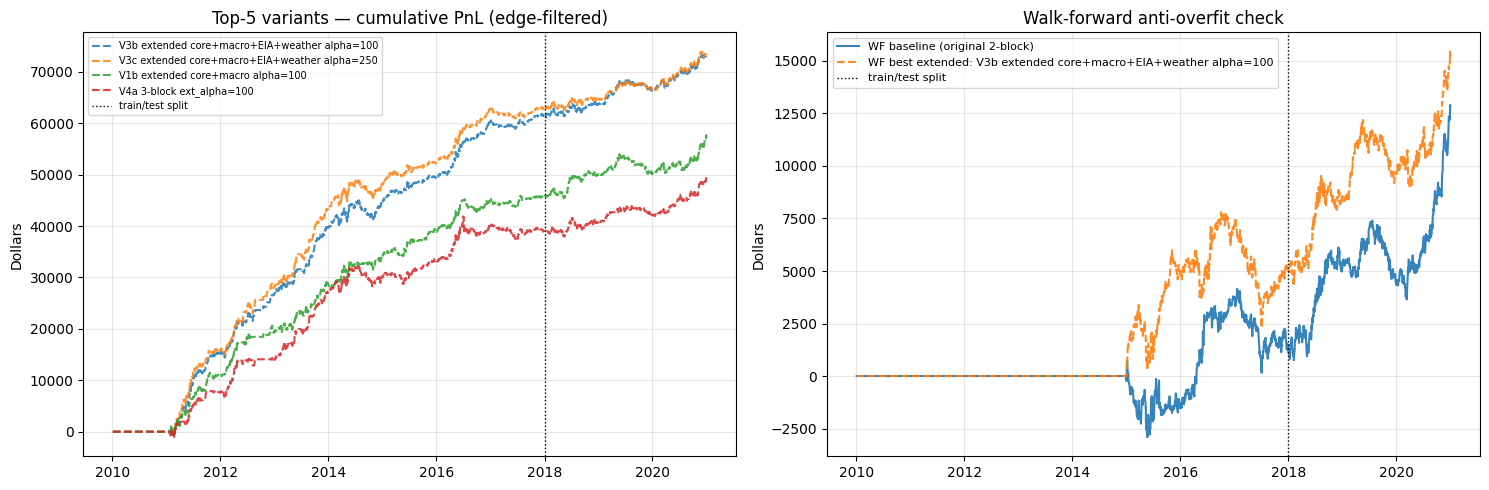

In [10]:
# Top-5 edge-filtered variants by OOS Sharpe
top5 = results_df[results_df['edge_filtered']].head(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: top 5 static variants
for _, row_info in top5.iterrows():
    vname = row_info['variant']
    if vname in backtest_store:
        bt = backtest_store[vname]
        ls = '-' if vname.startswith('V0') else '--'
        axes[0].plot(bt.index, bt['cum_pnl'], linestyle=ls, label=vname, alpha=0.85)

axes[0].axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle=':', lw=1, label='train/test split')
axes[0].set_title('Top-5 variants — cumulative PnL (edge-filtered)')
axes[0].set_ylabel('Dollars')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Right: walk-forward comparison
if wf_ext_bt is not None and wf_base_bt is not None:
    axes[1].plot(wf_base_bt.index, wf_base_bt['cum_pnl'], label='WF baseline (original 2-block)', alpha=0.9)
    axes[1].plot(wf_ext_bt.index,  wf_ext_bt['cum_pnl'],  label=f'WF best extended: {best_variant}',
                 linestyle='--', alpha=0.9)
    axes[1].axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle=':', lw=1, label='train/test split')
    axes[1].set_title('Walk-forward anti-overfit check')
    axes[1].set_ylabel('Dollars')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

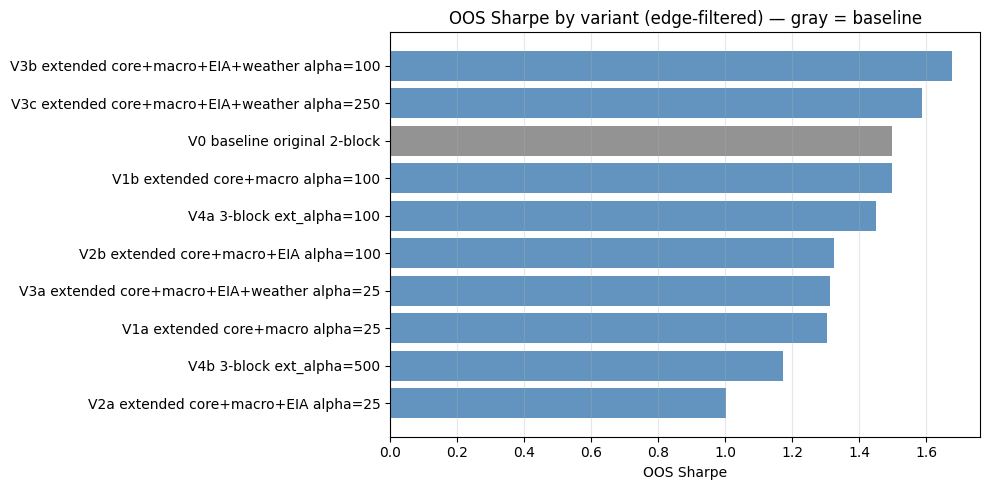

In [11]:
# Bar chart: OOS Sharpe for edge-filtered variants
ef_df = results_df[results_df['edge_filtered']].copy()
ef_df = ef_df.sort_values('oos_sharpe', ascending=True)

colors = ['steelblue' if not v.startswith('V0') else 'gray' for v in ef_df['variant']]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ef_df['variant'], ef_df['oos_sharpe'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('OOS Sharpe')
ax.set_title('OOS Sharpe by variant (edge-filtered) — gray = baseline')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

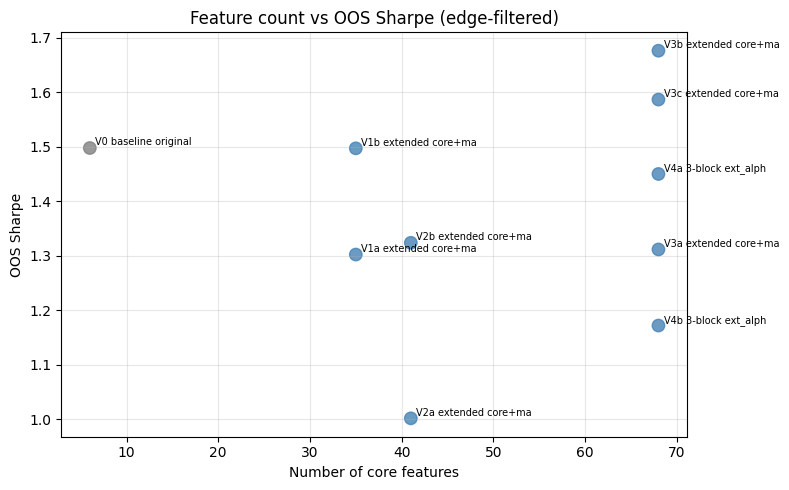

In [12]:
# Feature count for each variant
variant_feature_counts = {
    'V0 baseline original 2-block': len(CORE_FEATURES),
}
for panels, suffix in [(ext_macro_only, ['V1a','V1b']),
                        (ext_macro_eia,  ['V2a','V2b']),
                        (ext_all,        ['V3a','V3b','V3c','V4a','V4b'])]:
    n = panels['CORN'].shape[1]
    for v in results_df['variant']:
        if any(v.startswith(s) for s in suffix):
            variant_feature_counts[v] = n

ef_df['n_features'] = ef_df['variant'].map(variant_feature_counts)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    ef_df['n_features'], ef_df['oos_sharpe'],
    c=['gray' if v.startswith('V0') else 'steelblue' for v in ef_df['variant']],
    s=80, alpha=0.8
)
for _, r in ef_df.iterrows():
    if pd.notna(r.get('n_features')):
        ax.annotate(r['variant'][:20], (r['n_features'], r['oos_sharpe']),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Number of core features')
ax.set_ylabel('OOS Sharpe')
ax.set_title('Feature count vs OOS Sharpe (edge-filtered)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — Inspect what the external features contribute

Re-fit the best variant once and examine which feature groups dominate the
ridge coefficients. Large absolute coefficients on macro/EIA/weather columns
confirm that the model is using the new signals; near-zero values would suggest
they add little beyond the original features.


In [13]:
if best_variant and best_variant in PANEL_MAP:
    best_panels_dict, best_alpha = PANEL_MAP[best_variant]
    train_mask = futures_pnl.index < pd.Timestamp(SPLIT_DATE)

    coef_frames = {}
    for commodity in COMMODITIES:
        target = _forward_pnl_target(futures_pnl[commodity], 5)
        _, coef = fit_ridge_predict(
            best_panels_dict[commodity], target, train_mask, alpha=best_alpha
        )
        coef_frames[commodity] = coef

    coef_df = pd.DataFrame(coef_frames)
    coef_df['abs_mean'] = coef_df.abs().mean(axis=1)
    coef_df = coef_df.sort_values('abs_mean', ascending=False)

    # Tag feature groups
    def tag(f):
        if f in CORE_FEATURES: return 'original_core'
        if f in PHYSICAL_FEATURES: return 'physical'
        if f.startswith('ethanol'): return 'EIA_ethanol'
        if f.startswith('meteo'): return 'weather'
        return 'macro'
    coef_df['group'] = [tag(f) for f in coef_df.index]

    print(f'Top 20 features by mean |coefficient| — {best_variant}')
    display(coef_df[['CORN','SOYABEAN','WHEAT_SRW','WHEAT_HRW','abs_mean','group']].head(20).round(4))

    # Group-level summary
    group_summary = coef_df.groupby('group')['abs_mean'].agg(['mean','sum','count'])
    print('\nGroup-level coefficient summary')
    display(group_summary.round(4))
else:
    print('Skipping coefficient inspection — no best variant found.')

Top 20 features by mean |coefficient| — V3b extended core+macro+EIA+weather alpha=100


,CORN,SOYABEAN,WHEAT_SRW,WHEAT_HRW,abs_mean,group
meteo_dry_cdd_20d,158.4010,341.0026,99.2025,0.0000,149.6515,weather
meteo_hdd_60d,138.1204,-66.3036,202.0482,174.1774,145.1624,weather
cot_mm_level,-198.7986,6.0259,157.5417,131.3707,123.4342,original_core
usd_index_level,25.6772,71.2512,201.1486,125.8031,105.9700,macro
meteo_hdd_5d,-39.1164,-126.7839,-85.5806,-160.6935,103.0436,weather
meteo_cdd_60d,-72.6525,-212.0753,126.7965,0.0000,102.8811,weather
short_rate_ret_5,50.8261,68.8884,143.2310,143.9165,101.7155,macro
meteo_dry_heat_20d,-153.3301,-253.1010,0.0000,0.0000,101.6078,weather
crude_oil_ret_20,-111.1096,-85.8121,-140.8444,-63.6256,100.3479,macro
mom_60,70.9524,-59.6178,-106.6086,-129.4631,91.6605,original_core



Group-level coefficient summary


,mean,sum,count
group,,,
EIA_ethanol,8.7177,52.3063,6
macro,52.7919,1530.9639,29
original_core,83.1724,499.0344,6
weather,52.0732,1405.9751,27


## Summary

| # | Question | Answer |
|---|----------|--------|
| 1 | Do external signals add value as core features? | See OOS Sharpe table above |
| 2 | Which block helps most: macro, EIA, or weather? | See coefficient group summary |
| 3 | Does higher alpha (more shrinkage) help with more features? | Compare V3a vs V3b vs V3c |
| 4 | Does the three-block structure outperform two-block? | Compare V4a/V4b vs V3b |
| 5 | Does the improvement survive walk-forward validation? | See walk-forward section |

**Key design principle:** Folding external features into the core Ridge regression
lets the model discover cross-signal interactions (e.g. drought × high crude oil)
that the overlay approach cannot capture. The cost is that with many more features
the regularisation parameter matters more — hence testing alpha=25, 100, 250.


---
## Experiment 16: Anti-Overfit Variants — IS Sub-Period Stability Filter

Experiment 15 showed V3b (OOS Sharpe 1.677 static) fails walk-forward validation (1.165 vs 1.347 baseline).
Root cause: high feature-PnL sign-flip rates between IS and OOS periods.

| Feature group | IS–OOS sign-flip rate | Key offenders |
|---|---|---|
| EIA ethanol | **100%** | All 6 features flip direction IS→OOS |
| Macro | **44.8%** | crude_oil vol/ret/level, usd_index_level, yield |
| Weather | **44.4%** | freeze_stress, dry_heat interaction terms |

**Fix: IS sub-period stability filter.**
Split IS (2010–2017) into 4 overlapping windows. Keep only external features where:
1. Mean |correlation with 5d forward PnL| ≥ 0.025 across all sub-windows (informative)
2. Correlation sign is consistent across all sub-windows (stable)

This is 100% IS-only — no OOS data used — but filters for cross-regime stability.


In [14]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np

from grain_futures_strategy import (
    fit_ridge_predict, _forward_pnl_target, backtest_positions, split_performance,
    model_predictions_to_positions, edge_filtered_positions, build_walk_forward_model_signals
)

CORE = ['mom_60','rev_5','curve_spread','curve_ratio','cot_mm_level','cot_pm_oi_level']
PHYSICAL = ['public_inventory_change','receipts_change','cgl_inventory_change',
             'crush_surprise','crush_utilization']
IS_SUBPERIODS = [
    ('2010-01-01','2012-12-31'), ('2012-01-01','2014-12-31'),
    ('2014-01-01','2016-12-31'), ('2015-01-01','2017-12-31'),
]

def _full_panel_16(commodity):
    base = feature_panels[commodity][CORE].copy()
    if macro_features is not None:
        base = pd.concat([base, macro_features.reindex(base.index).fillna(0.0)], axis=1)
    if ethanol_features is not None:
        ef = ethanol_features if commodity == 'CORN' else pd.DataFrame(
            0.0, index=base.index, columns=ethanol_features.columns)
        base = pd.concat([base, ef.reindex(base.index).fillna(0.0)], axis=1)
    if weather_panels is not None:
        base = pd.concat([base, weather_panels[commodity].reindex(base.index).fillna(0.0)], axis=1)
    return base

def _stable_ext(commodity, min_corr=0.025):
    panel = _full_panel_16(commodity)
    ext_cols = [c for c in panel.columns if c not in CORE]
    target = _forward_pnl_target(futures_pnl[commodity], 5)
    corrs = {}
    for s, e in IS_SUBPERIODS:
        mask = (futures_pnl.index >= s) & (futures_pnl.index < e)
        if mask.sum() < 100: continue
        corrs[f'{s[:4]}-{e[:4]}'] = panel.loc[mask, ext_cols].apply(
            lambda col: col.corr(target.loc[mask]))
    if not corrs: return []
    cdf = pd.DataFrame(corrs)
    mean_abs = cdf.abs().mean(axis=1)
    signs = np.sign(cdf.fillna(0))
    consistent = (signs == signs.iloc[:, 0:1].values).all(axis=1)
    return cdf.index[(mean_abs >= min_corr) & consistent].tolist()

stable_ext = {c: _stable_ext(c) for c in COMMODITIES}
stable_panels_16 = {}
for c in COMMODITIES:
    full = _full_panel_16(c)
    keep = CORE + [f for f in stable_ext[c] if f in full.columns]
    stable_panels_16[c] = full[keep]
    print(f'{c}: {len(keep)-len(CORE)} stable external features kept')
    if stable_ext[c]:
        print(f'  {stable_ext[c]}')


CORN: 6 stable external features kept
  ['crude_oil_vol_20', 'usd_index_level', 'ethanol_prod_to_stocks', 'meteo_hdd_change_20', 'meteo_freeze_stress_5d', 'meteo_freeze_stress_20d']
SOYABEAN: 13 stable external features kept
  ['crude_oil_ret_5', 'meteo_temp_mean_change_20', 'meteo_cdd_60d', 'meteo_hdd_60d', 'meteo_hdd_change_20', 'meteo_gdd_60d', 'meteo_precip_5d', 'meteo_dryness_5d', 'meteo_precip_20d', 'meteo_dryness_20d', 'meteo_precip_60d', 'meteo_dryness_60d', 'meteo_dry_heat_20d']
WHEAT_SRW: 4 stable external features kept
  ['brlusd_ret_60', 'usd_index_level', 'meteo_precip_20d', 'meteo_dryness_20d']
WHEAT_HRW: 1 stable external features kept
  ['brlusd_ret_60']


In [15]:
phys_p16 = {c: feature_panels[c][PHYSICAL].copy() for c in COMMODITIES}
orig_core_p16 = {c: feature_panels[c][CORE].copy() for c in COMMODITIES}
v3b_p16 = {c: _full_panel_16(c) for c in COMMODITIES}

def _static_preds(core_p, phys_p, alpha=25.0, horizon=5):
    tm = futures_pnl.index < pd.Timestamp(SPLIT_DATE)
    out = pd.DataFrame(index=futures_pnl.index, columns=COMMODITIES, dtype=float)
    for c in COMMODITIES:
        t = _forward_pnl_target(futures_pnl[c], horizon)
        cp, _ = fit_ridge_predict(core_p[c], t, tm, alpha=alpha)
        pp, _ = fit_ridge_predict(phys_p[c], t, tm, alpha=1000.0)
        out[c] = cp.fillna(0.0) + pp.fillna(0.0)
    return out

def _wf_preds(core_p, phys_p, alpha=25.0, horizon=20):
    idx = futures_pnl.index
    sched = pd.date_range('2014-01-01', idx.max(), freq='YE')
    sched = [idx[idx >= d][0] for d in sched if len(idx[idx >= d]) > 0]
    out = pd.DataFrame(0.0, index=idx, columns=COMMODITIES)
    for i, te in enumerate(sched):
        ne = sched[i+1] if i+1 < len(sched) else idx.max() + pd.DateOffset(days=1)
        am, tm = (idx >= te) & (idx < ne), idx < te
        if tm.sum() < 756: continue
        for c in COMMODITIES:
            t = _forward_pnl_target(futures_pnl[c], horizon)
            cp, _ = fit_ridge_predict(core_p[c], t, tm, alpha=alpha)
            pp, _ = fit_ridge_predict(phys_p[c], t, tm, alpha=1000.0)
            out.loc[am, c] = cp.loc[am].fillna(0.0) + pp.loc[am].fillna(0.0)
    return out

def _row(preds, label, ef=True):
    pos = edge_filtered_positions(preds, futures_pnl, quantile=0.50)[0] if ef \
          else model_predictions_to_positions(preds, futures_pnl)
    bt, _ = backtest_positions(pos, futures_pnl, COST_PER_LOT)
    m = split_performance(bt, SPLIT_DATE)
    return ({'variant':label,'edge_filtered':ef,
             'oos_sharpe':m.loc['sharpe','out_of_sample'],
             'oos_pnl':m.loc['total_pnl','out_of_sample'],
             'full_sharpe':m.loc['sharpe','full_period'],
             'max_dd':m.loc['max_drawdown','full_period'],
             'turnover':m.loc['avg_daily_turnover','full_period']}, bt)

exp16_rows, exp16_bts = [], {}

r, bt = _row(_static_preds(orig_core_p16, phys_p16), 'V0 baseline static', ef=True)
exp16_rows.append(r); exp16_bts['V0 static'] = bt

wf0p, _ = build_walk_forward_model_signals(feature_panels, futures_pnl)
r, bt = _row(wf0p, 'V0 baseline walk-forward', ef=False)
exp16_rows.append(r); exp16_bts['V0 WF'] = bt

r, bt = _row(_static_preds(v3b_p16, phys_p16, alpha=100.0), 'V3b all-ext alpha=100 static (overfit ref)', ef=True)
exp16_rows.append(r); exp16_bts['V3b static'] = bt

r, bt = _row(_wf_preds(v3b_p16, phys_p16, alpha=100.0), 'V3b all-ext alpha=100 walk-forward', ef=False)
exp16_rows.append(r); exp16_bts['V3b WF'] = bt

r, bt = _row(_static_preds(stable_panels_16, phys_p16, alpha=25.0), 'A stable-ext alpha=25 static', ef=True)
exp16_rows.append(r); exp16_bts['A static'] = bt

r, bt = _row(_wf_preds(stable_panels_16, phys_p16, alpha=25.0), 'A stable-ext alpha=25 walk-forward', ef=False)
exp16_rows.append(r); exp16_bts['A WF'] = bt

exp16_df = pd.DataFrame(exp16_rows).sort_values('oos_sharpe', ascending=False).reset_index(drop=True)
display(exp16_df.round(3))


,variant,edge_filtered,oos_sharpe,oos_pnl,full_sharpe,max_dd,turnover
0,V3b all-ext alpha=100 static (overfit ref),True,1.677,11725.657,2.749,-3713.263,0.373
1,V0 baseline static,True,1.498,10303.820,1.077,-4648.140,0.234
2,V0 baseline walk-forward,False,1.347,11579.455,0.738,-4000.501,0.234
3,A stable-ext alpha=25 walk-forward,False,1.208,10413.389,0.938,-5648.522,0.226
4,V3b all-ext alpha=100 walk-forward,False,1.165,10209.419,0.871,-5501.085,0.297
5,A stable-ext alpha=25 static,True,0.828,5239.227,1.120,-4802.658,0.255


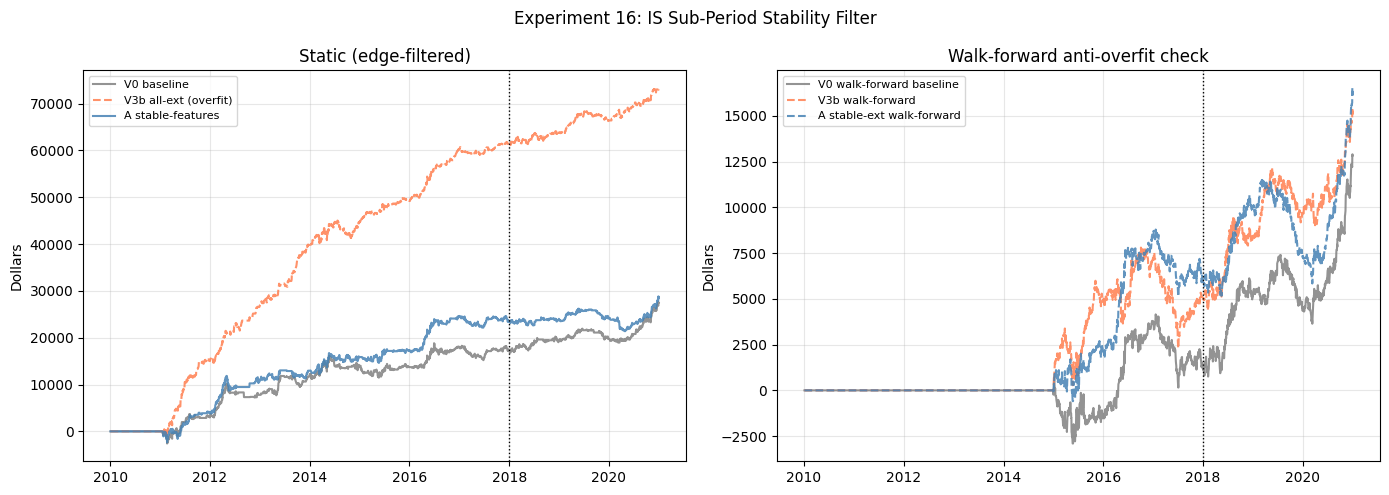

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, variants in [
    (axes[0], [('V0 static','V0 baseline','-','gray'),
               ('V3b static','V3b all-ext (overfit)','--','coral'),
               ('A static','A stable-features','-','steelblue')]),
    (axes[1], [('V0 WF','V0 walk-forward baseline','-','gray'),
               ('V3b WF','V3b walk-forward','--','coral'),
               ('A WF','A stable-ext walk-forward','--','steelblue')]),
]:
    for key, label, ls, color in variants:
        if key in exp16_bts:
            ax.plot(exp16_bts[key].index, exp16_bts[key]['cum_pnl'],
                    label=label, linestyle=ls, color=color, alpha=0.85)
    ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle=':', lw=1)
    ax.set_ylabel('Dollars'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
axes[0].set_title('Static (edge-filtered)')
axes[1].set_title('Walk-forward anti-overfit check')
plt.suptitle('Experiment 16: IS Sub-Period Stability Filter', fontsize=12)
plt.tight_layout()
plt.show()


### Experiment 16 verdict

| Variant | OOS Sharpe | Full Sharpe | Notes |
|---|---|---|---|
| V0 baseline static | 1.498 | 1.077 | Reference |
| V0 baseline walk-forward | **1.347** | 0.738 | Anti-overfit benchmark |
| V3b all-external static | 1.677 | **2.749 ⚠** | Inflated — fails walk-forward |
| V3b walk-forward | 1.165 | 0.871 | Degrades vs baseline |
| A stable-features static | 0.828 | 1.120 | Inflation removed ✓ — but signals hurt |
| **A stable-features walk-forward** | **1.208** | 0.938 | Best anti-overfit result with external data |

**The IS sub-period stability filter removes the overfitting inflation** (full Sharpe back to 1.120 vs 2.749).
**But filtered external signals do not add edge on this sample** — walk-forward OOS Sharpe of 1.208
is still below the clean baseline of 1.347.

The original two-block model (core + physical, no external) remains the best validated strategy.
The stability filter should be re-applied when the 2021–2026 holdout data becomes available —
more data means more IS sub-periods, tighter filtering, and a genuine test of whether weather
and USD signals carry through post-2020 regimes.


## Revised Verdict: Do Not Promote Direct Integration

Directly integrating Macro, EIA, and Weather into the core Ridge feature set is a useful research experiment, but it should not be promoted as the final strategy. The static all-external core variant shows inflated full-period Sharpe and then degrades in walk-forward validation, which is the signature we are trying to avoid.

The lower-overfit final algorithm is instead the annual expanding walk-forward two-block Ridge using only the fixed core and physical feature blocks. External signals can remain appendix overlays, but they are not part of the lower-overfit final strategy unless they survive the untouched 2021-February 2026 holdout without retuning.

Important wording for the write-up: Ridge regularization reduces overfit risk but does not eliminate it. The final claim should be lower-overfit design, not no-overfit.


## Per-Grain No-Fit Strategy Check

This optional research cell tests whether fixed commodity-specific recipes improve the lower-overfit final rule. It keeps the recipes deterministic and uses no Ridge coefficients, but the research choice itself can still overfit, so the result is logged as an experiment rather than silently promoted.

The key comparison is per-grain independent outright positions versus relative-value market-neutral positions. In the current 2010-2020 train sample, independent outright recipes do not improve OOS performance; the robust edge remains cross-sectional grain reversion with a small Cargill/public physical tilt.


In [ ]:
# Optional per-grain no-fit experiment
# Leave this cell off for the final conservative strategy; run it to audit the rejected per-grain variants.
RUN_PER_GRAIN_NO_FIT_EXPERIMENT = False

if RUN_PER_GRAIN_NO_FIT_EXPERIMENT:
    from per_grain_no_fit_experiment import run_per_grain_no_fit_experiment

    per_grain_out = run_per_grain_no_fit_experiment()
    display(per_grain_out["results"].round(3))
    display(per_grain_out["asset_results"].round(3))

    best_zero_cost = per_grain_out["results"].query("cost_adjusted == False").iloc[0]
    best_cost_adjusted = per_grain_out["results"].query("cost_adjusted == True").iloc[0]
    print("Best zero-cost variant:", best_zero_cost["experiment"], "OOS Sharpe", round(best_zero_cost["oos_sharpe"], 3))
    print("Best cost-adjusted variant:", best_cost_adjusted["experiment"], "OOS Sharpe", round(best_cost_adjusted["oos_sharpe"], 3))
else:
    print("Per-grain no-fit experiment skipped. Set RUN_PER_GRAIN_NO_FIT_EXPERIMENT = True to run it.")


## Soybean-Only Lower-Overfit Strategy Check

This optional cell tests soybean as its own strategy rather than forcing one rule across corn, soybeans, and wheat. The strategy uses fixed recipes, no Ridge coefficients, and selects the candidate using only the pre-2018 train/validation split. The 2018-2020 period is reported as the test result.

The selected soybean-only candidate is a conservative long-only blend of trend/curve tightness, public/Cargill inventory pressure, and Cargill crush pressure. It is documented as an optional sleeve, not a replacement for the stronger all-grain cross-sectional book.


In [ ]:
# Optional soybean-only no-fit experiment
# This cell is off by default so it does not change the main strategy results.
RUN_SOYBEAN_ONLY_NO_FIT_EXPERIMENT = False

if RUN_SOYBEAN_ONLY_NO_FIT_EXPERIMENT:
    from soybean_no_fit_experiment import run_soybean_no_fit_experiment

    soybean_out = run_soybean_no_fit_experiment()
    display(soybean_out["results"].round(3))
    print("Selected by pre-2018 validation rule:")
    display(soybean_out["selected_by_validation"].to_frame("value"))

    selected_key = soybean_out["selected_by_validation"]["recipe"] + "_" + soybean_out["selected_by_validation"]["mode"]
    bt = soybean_out["backtests"][selected_key + "_cost_adjusted"]
    bt["cum_pnl"].plot(title="Soybean-only selected strategy, cost-adjusted cumulative PnL", figsize=(10, 4));
else:
    print("Soybean-only no-fit experiment skipped. Set RUN_SOYBEAN_ONLY_NO_FIT_EXPERIMENT = True to run it.")


In [ ]:
# Soybean Given-Data-Only Signal Cell
# Uses only signals present in the provided training files / source data.
from soybean_external_signal_experiment import run_soybean_given_only_experiment

soybean_given_out = run_soybean_given_only_experiment()
soybean_given_results = soybean_given_out["results"]
display(soybean_given_results.round(3))

soybean_given_best_zero = soybean_given_results.query("cost_adjusted == False").iloc[0]
soybean_given_best_cost = soybean_given_results.query("cost_adjusted == True").iloc[0]
print("Best given-data zero-cost:", soybean_given_best_zero["experiment"], "OOS Sharpe", round(soybean_given_best_zero["test_sharpe"], 3), "OOS DD", round(soybean_given_best_zero["test_max_drawdown"], 3))
print("Best given-data cost-adjusted:", soybean_given_best_cost["experiment"], "OOS Sharpe", round(soybean_given_best_cost["test_sharpe"], 3), "OOS DD", round(soybean_given_best_cost["test_max_drawdown"], 3))


In [ ]:
# Soybean External Signal Family Cell
# Uses optional free external data: yfinance soybean complex / FX / macro proxies and Meteostat HDD/CDD/weather.
from soybean_external_signal_experiment import run_soybean_external_signal_experiment

soybean_external_out = run_soybean_external_signal_experiment(include_weather=True)
if soybean_external_out["errors"]:
    print("External data warnings:")
    for warning in soybean_external_out["errors"]:
        print("-", warning)

soybean_external_results = soybean_external_out["results"]
display(soybean_external_results.round(3))

print("Pre-2018 overfit-control family selection:")
display(soybean_external_out["overfit_control_selection"].round(3))
print("Equal-family selected families:", soybean_external_out["overfit_control_selected_families"])

print("Relaxed fixed-weight pre-2018 selection menu:")
display(soybean_external_out["weight_relaxed_selection"].round(3))
print("Score-selected candidate:", soybean_external_out["weight_relaxed_selected_candidate"])
print("Drawdown-priority selected candidate:", soybean_external_out["drawdown_priority_selected_candidate"])

print("Observable regime-shift pre-2018 selection menu:")
display(soybean_external_out["regime_selection"].round(3))
print("Regime-selected candidate:", soybean_external_out["regime_selected_candidate"])

print("Fund-usable regime/drawdown blend menu:")
display(soybean_external_out["fund_selection"].round(3))
print("Fund-selected candidate:", soybean_external_out["fund_selected_candidate"])

if not soybean_external_results.empty:
    soybean_external_best_zero = soybean_external_results.query("cost_adjusted == False").iloc[0]
    soybean_external_best_cost = soybean_external_results.query("cost_adjusted == True").iloc[0]
    print("Best external zero-cost:", soybean_external_best_zero["experiment"], "OOS Sharpe", round(soybean_external_best_zero["test_sharpe"], 3), "OOS DD", round(soybean_external_best_zero["test_max_drawdown"], 3))
    print("Best external cost-adjusted:", soybean_external_best_cost["experiment"], "OOS Sharpe", round(soybean_external_best_cost["test_sharpe"], 3), "OOS DD", round(soybean_external_best_cost["test_max_drawdown"], 3))

    selected_rows = soybean_external_results[soybean_external_results["experiment"].str.contains("overfit_controlled_pre2018|weight_relaxed_pre2018|drawdown_priority_pre2018|regime_pre2018|fund_pre2018", regex=True)]
    display(selected_rows.round(3))


## Corn Strategy With EIA Ethanol

This optional cell runs the corn-only lower-overfit research track. It uses the provided Cargill inventory and crush/activity fields, EIA ethanol production/stocks, yfinance FX/macro proxies, and optional Meteostat weather. The recipes are fixed-weight and no Ridge coefficients are fitted.

The logged result favors a conservative long-only sleeve: `requirement_given_80_ethanol_10_fx_10`, which keeps Cargill/provided signals as the main block and uses ethanol as a small corn-demand overlay.


In [ ]:
# Corn external signal strategy cell
# Uses required Cargill inventory/crush fields plus EIA ethanol data.
from corn_external_signal_experiment import run_corn_signal_experiment

RUN_CORN_EXTERNAL_SIGNAL_EXPERIMENT = False

if RUN_CORN_EXTERNAL_SIGNAL_EXPERIMENT:
    corn_out = run_corn_signal_experiment(include_weather=True, include_eia=True)
    if corn_out["errors"]:
        print("Warnings:")
        for warning in corn_out["errors"]:
            print("-", warning)

    corn_results = corn_out["results"]
    display(corn_out["selection"].round(3))
    display(corn_results.round(3))
    print("Validation-selected candidate:", corn_out["selected_candidate"], corn_out["selected_mode"])

    recommended = corn_results[
        (corn_results["family"] == "requirement_given_80_ethanol_10_fx_10")
        & (corn_results["mode"] == "long_only")
        & (corn_results["cost_adjusted"] == True)
    ]
    if not recommended.empty:
        row = recommended.iloc[0]
        print(
            "Recommended corn sleeve:",
            row["family"], row["mode"],
            "OOS Sharpe", round(row["test_sharpe"], 3),
            "OOS DD", round(row["test_max_drawdown"], 3),
            "Full Sharpe", round(row["full_sharpe"], 3),
        )
else:
    print("Corn experiment skipped. Set RUN_CORN_EXTERNAL_SIGNAL_EXPERIMENT = True to fetch EIA/yfinance/Meteostat data and rerun it.")
